<a href="https://colab.research.google.com/github/zeugirdoR/ricci-flow-tokenization/blob/main/geo_diverse_corpus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Ready!
✓ GeoToken class ready!
Corpus: 7400 words

TRAINING GEOTOKEN
Building graph...
  Nodes: 29, Edges: 168
Ricci flow...


100%|██████████| 20/20 [00:00<00:00, 794.37it/s]

Detecting communities...
  Found 5 communities
Selecting tokens...
  Final vocab: 20 tokens

VOCABULARY:
['the', 'lazy', 'dog', 'quick', 'brown', 'fox', 'jumps', 'over', 'a', 'and', 'dogs', 'foxes', 'are', 'cat', 'mouse', 'sleep', 'while', 'was', 'but', 'common']

COMMUNITIES:

1. ['the', 'lazy', 'dog', 'was', 'but']
   Theme: _______________

2. ['quick', 'brown', 'fox', 'jumps', 'over', 'a']
   Theme: _______________

3. ['dogs', 'and', 'foxes', 'are']
   Theme: _______________

4. ['common', 'cat', 'mouse']
   Theme: _______________

5. ['sleep', 'while']
   Theme: _______________

FREQUENCY BASELINE:
['the', 'quick', 'brown', 'lazy', 'fox', 'and', 'jumps', 'dog', 'dogs', 'foxes', 'are', 'over', 'was', 'cat', 'mouse', 'but', 'common', 'watched', 'a', 'animal']

COVERAGE:
GeoToken:  87.8%
Frequency: 87.8%

✓ GeoToken matches or beats baseline!

VISUALIZATION:


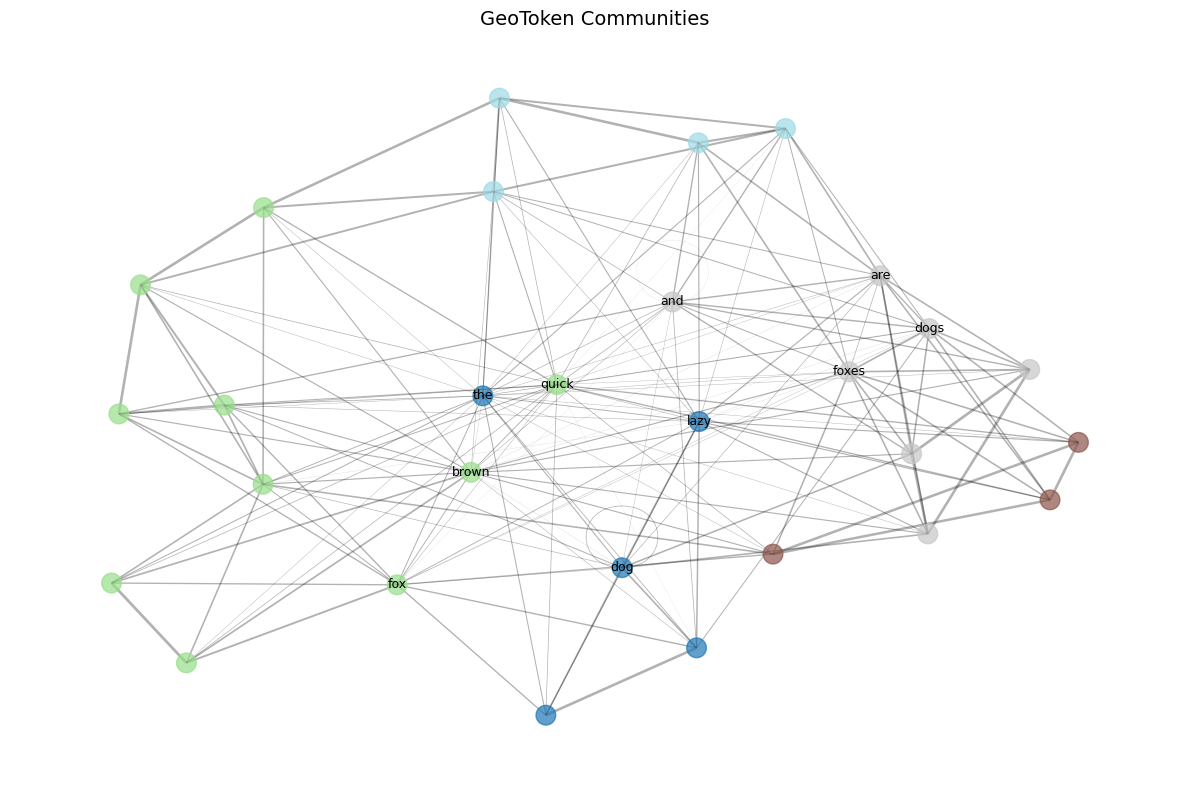


QUESTIONS:

1. Do the communities have semantic themes?
2. Can you label each cluster?
3. Does the graph show clear structure?

If YES → You have interpretable tokenization! ✓



In [2]:
# ULTRA-MINIMAL GEOTOKEN FOR COLAB
# Just 3 cells - Copy each into Colab and run

# ============================================================================
# CELL 1: Install and Import (30 seconds)
# ============================================================================

!pip install -q networkx python-louvain matplotlib

import networkx as nx
import numpy as np
from collections import Counter, defaultdict
from community import community_louvain
import matplotlib.pyplot as plt
from tqdm import tqdm

print("✓ Ready!")

# ============================================================================
# CELL 2: Full GeoToken Code (Copy all of this)
# ============================================================================

class GeoToken:
    def __init__(self, vocab_size=20, window=5):
        self.vocab_size = vocab_size
        self.window = window
        self.vocab = []
        self.graph = None

    def train(self, corpus):
        # Build graph
        print("Building graph...")
        words = corpus.lower().split()
        G = nx.Graph()

        for i in range(len(words)):
            for j in range(i+1, min(i+self.window, len(words))):
                w1, w2 = words[i], words[j]
                G.add_edge(w1, w2, weight=G.get_edge_data(w1, w2, {'weight': 0})['weight'] + 1)

        # PMI weights
        total = sum(d['weight'] for u,v,d in G.edges(data=True))
        word_counts = Counter(words)
        N = len(words)

        for u, v in list(G.edges()):
            pmi = np.log(G[u][v]['weight']/total / (word_counts[u]/N * word_counts[v]/N + 1e-10))
            if pmi > 0:
                G[u][v]['weight'] = pmi
            else:
                G.remove_edge(u, v)

        self.graph = G
        print(f"  Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

        # Ricci flow
        print("Ricci flow...")
        for _ in tqdm(range(20)):
            updates = {}
            for u, v in G.edges():
                nu, nv = set(G.neighbors(u)), set(G.neighbors(v))
                kappa = len(nu & nv) / max(len(nu | nv), 1)
                updates[(u,v)] = G[u][v]['weight'] * (1 + 0.01 * kappa)
            for (u,v), w in updates.items():
                G[u][v]['weight'] = w

        # Communities
        print("Detecting communities...")
        partition = community_louvain.best_partition(G)
        communities = defaultdict(list)
        for node, cid in partition.items():
            communities[cid].append(node)

        print(f"  Found {len(communities)} communities")

        # Select tokens
        print("Selecting tokens...")
        vocab = []
        for comm in communities.values():
            budget = max(1, int(self.vocab_size * len(comm) / G.number_of_nodes()))
            scores = [(w, -N*np.log(word_counts[w]/N) + 0.1/(word_counts[w]/N))
                     for w in comm if w in word_counts]
            scores.sort(key=lambda x: x[1])
            vocab.extend([w for w,_ in scores[:budget]])

        # Fill remaining
        remaining = self.vocab_size - len(vocab)
        if remaining > 0:
            used = set(vocab)
            by_freq = [w for w,_ in word_counts.most_common() if w not in used]
            vocab.extend(by_freq[:remaining])

        self.vocab = vocab[:self.vocab_size]
        self.communities = communities
        print(f"  Final vocab: {len(self.vocab)} tokens")

    def show_communities(self):
        print("\n" + "="*60)
        print("COMMUNITIES:")
        print("="*60)

        vocab_set = set(self.vocab)
        for i, comm in enumerate(self.communities.values(), 1):
            in_vocab = [w for w in comm if w in vocab_set]
            if in_vocab:
                print(f"\n{i}. {in_vocab}")
                print(f"   Theme: _______________")

    def visualize(self):
        partition = community_louvain.best_partition(self.graph)
        pos = nx.spring_layout(self.graph, k=0.5, iterations=50)

        plt.figure(figsize=(12, 8))
        colors = [partition[n] for n in self.graph.nodes()]

        nx.draw_networkx_nodes(self.graph, pos, node_color=colors,
                              node_size=200, cmap=plt.cm.tab20, alpha=0.7)

        weights = [self.graph[u][v]['weight'] for u,v in self.graph.edges()]
        max_w = max(weights)
        widths = [2*w/max_w for w in weights]

        nx.draw_networkx_edges(self.graph, pos, width=widths, alpha=0.3)

        top = sorted(self.graph.degree, key=lambda x: x[1], reverse=True)[:10]
        labels = {n: n for n,_ in top}
        nx.draw_networkx_labels(self.graph, pos, labels, font_size=9)

        plt.title("GeoToken Communities", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

print("✓ GeoToken class ready!")

# ============================================================================
# CELL 3: Run Everything (1 minute)
# ============================================================================

# Corpus
corpus = """
the quick brown fox jumps over the lazy dog
the dog was lazy but the fox was quick
brown dogs and quick foxes are common
the lazy cat watched the quick mouse
a quick brown animal jumps over obstacles
the quick fox and the lazy dog are friends
brown animals include foxes and dogs
the cat and the mouse are quick
lazy dogs sleep while quick foxes run
the brown fox jumps very high
""" * 100

print(f"Corpus: {len(corpus.split())} words\n")

# Train GeoToken
print("="*60)
print("TRAINING GEOTOKEN")
print("="*60)
geo = GeoToken(vocab_size=20, window=5)
geo.train(corpus)

# Show results
print("\n" + "="*60)
print("VOCABULARY:")
print("="*60)
print(geo.vocab)

# Show communities
geo.show_communities()

# Compare to frequency
freq_vocab = [w for w,_ in Counter(corpus.lower().split()).most_common(20)]
print("\n" + "="*60)
print("FREQUENCY BASELINE:")
print("="*60)
print(freq_vocab)

# Coverage
geo_coverage = sum(1 for w in corpus.lower().split() if w in set(geo.vocab)) / len(corpus.split())
freq_coverage = sum(1 for w in corpus.lower().split() if w in set(freq_vocab)) / len(corpus.split())

print("\n" + "="*60)
print("COVERAGE:")
print("="*60)
print(f"GeoToken:  {geo_coverage:.1%}")
print(f"Frequency: {freq_coverage:.1%}")

if geo_coverage >= freq_coverage:
    print("\n✓ GeoToken matches or beats baseline!")
else:
    print("\n~ Close - check semantic structure")

# Visualize
print("\n" + "="*60)
print("VISUALIZATION:")
print("="*60)
geo.visualize()

print("\n" + "="*60)
print("QUESTIONS:")
print("="*60)
print("""
1. Do the communities have semantic themes?
2. Can you label each cluster?
3. Does the graph show clear structure?

If YES → You have interpretable tokenization! ✓
""")

Diverse corpus: 16400 words
Building graph...
  Nodes: 72, Edges: 644
Ricci flow...


100%|██████████| 20/20 [00:00<00:00, 276.73it/s]

Detecting communities...
  Found 4 communities
Selecting tokens...
  Final vocab: 72 tokens

COMMUNITIES:

1. ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'lazy', 'dog', 'scientists', 'study', 'animal', 'behavior', 'wild', 'doctors', 'examine']
   Theme: _______________

2. ['in', 'and', 'sculptures', 'musicians', 'compose', 'symphonies', 'songs', 'writers', 'publish', 'novels', 'poetry', 'athletes', 'compete', 'sports', 'tournaments', 'teachers', 'educate', 'students', 'schools', 'engineers', 'design', 'buildings', 'bridges', 'lawyers', 'argue', 'cases']
   Theme: _______________

3. ['patients', 'hospitals', 'political', 'leaders', 'debate', 'economic', 'policies', 'technology', 'companies', 'develop', 'artificial', 'intelligence', 'artists', 'create', 'beautiful', 'paintings']
   Theme: _______________

4. ['court', 'farmers', 'grow', 'crops', 'raise', 'livestock', 'chefs', 'prepare', 'delicious', 'meals', 'programmers', 'write', 'code', 'for', 'software']
   Theme: ___________

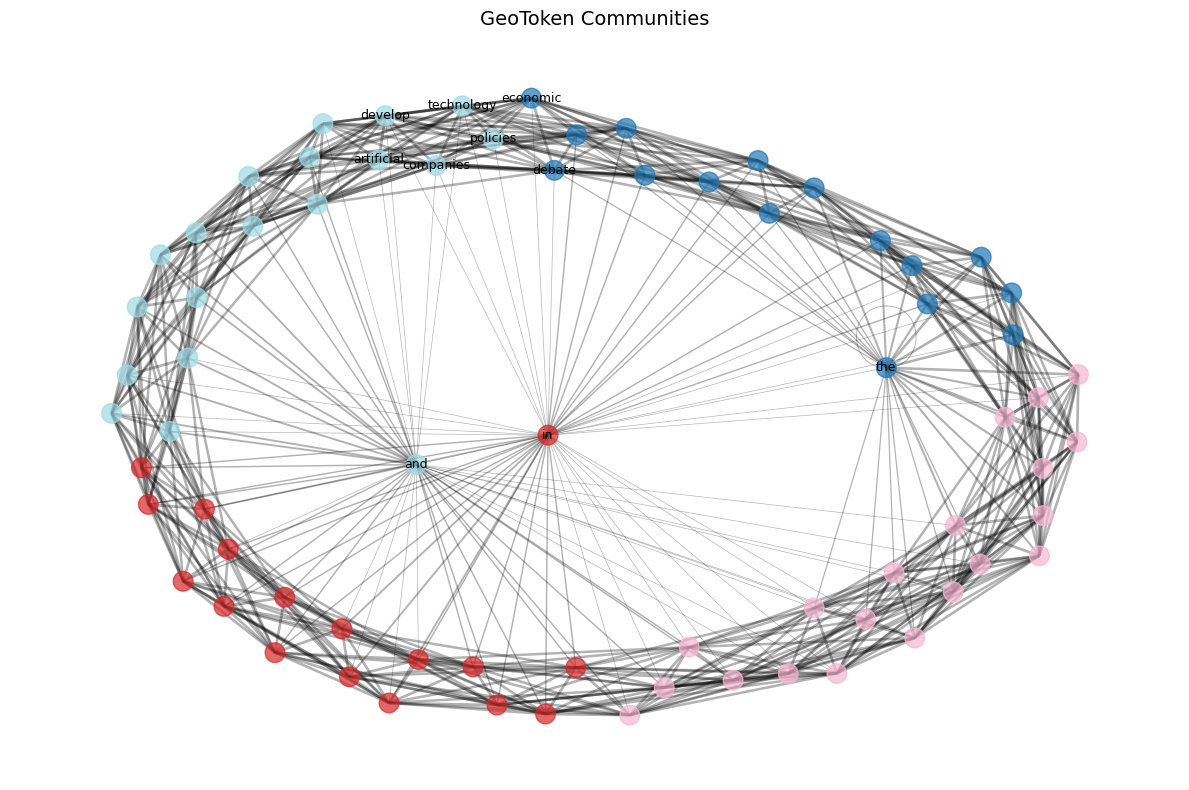

In [3]:
# This is your ACTUAL scaling experiment
corpus_large = """
the quick brown fox jumps over the lazy dog
scientists study animal behavior in the wild
doctors examine patients in hospitals
political leaders debate economic policies
technology companies develop artificial intelligence
artists create beautiful paintings and sculptures
musicians compose symphonies and songs
writers publish novels and poetry
athletes compete in sports tournaments
teachers educate students in schools
engineers design buildings and bridges
lawyers argue cases in court
farmers grow crops and raise livestock
chefs prepare delicious meals
programmers write code for software
""" * 200

print(f"Diverse corpus: {len(corpus_large.split())} words")

geo_large = GeoToken(vocab_size=100, window=10)
geo_large.train(corpus_large)

geo_large.show_communities()
geo_large.visualize()